In [76]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/hindusi"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection\hindusi


In [77]:
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"

test_images = root / "test" / "images"
test_labels = root / "test" / "labels"
print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection\hindusi\train\images
Train labels path: Sign Language Detection\hindusi\train\labels


Wytrenowany model do detekcji współrzędnych dłoni

In [78]:
import tensorflow as tf

# Wczytanie modelu
hand_detector = tf.keras.models.load_model('hand_detector_best.keras')
hand_detector

<Functional name=functional_1, built=True>

In [80]:
for p in [train_images, train_labels]:
    if not p.exists():
        print("Warning: path not found ->", p)

print("Train images:", len(list(train_images.glob("*.*"))))

Train images: 837


Showing sample: -d015f826-85af-11ef-9e5d-8cec4b00b636_jpg.rf.78a90cff22eae8e2872f3b0d7b095118.jpg


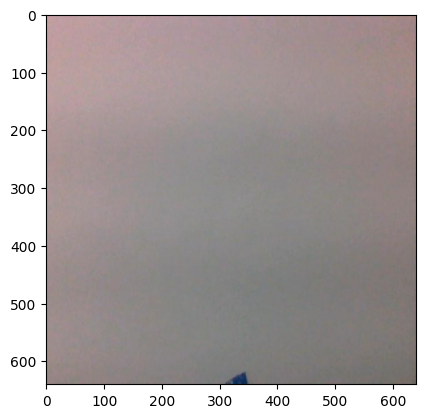

In [81]:
import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")
    print("Showing sample:", sample_img.name)
    plt.imshow(plt.imread(sample_img))
else:
    print("No images found in train/images.")

In [82]:
IMG_SIZE = 224

In [86]:
NUMBER_OF_CLASSES = 41

In [87]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Zakładamy, że detektor był trenowany na 224x224 (zgodnie z naszą poprzednią rozmową)
DETECTOR_SIZE = (224, 224) 

def load_data_with_detection(img_dir, label_dir, detector_model):
    images = []
    labels = []
    
    img_files = sorted(list(img_dir.glob("*.*")))
    
    print(f"Przetwarzanie {len(img_files)} obrazów z detekcją dłoni...")

    for i, img_path in enumerate(img_files):
        # 1. Wczytanie oryginalnego obrazu
        # Używamy imread z flagą, by upewnić się, że wczytuje 3 kanały
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None: continue
        
        h_orig, w_orig, _ = img_bgr.shape
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # ---------------------------------------------------------
        # ETAP 1: DETEKCJA (Szukamy dłoni)
        # ---------------------------------------------------------
        
        # Przygotowanie pod detektor (Resize do 224x224 + Normalizacja)
        input_for_detector = cv2.resize(img_rgb, DETECTOR_SIZE) / 255.0
        input_for_detector = np.expand_dims(input_for_detector, axis=0) # Dodanie wymiaru batcha [1, 224, 224, 3]

        # Predykcja ramki [x, y, w, h] (wartości 0.0 - 1.0)
        box_norm = detector_model.predict(input_for_detector, verbose=0)[0]
        
        # Konwersja na piksele
        x = int(box_norm[0] * w_orig)
        y = int(box_norm[1] * h_orig)
        w = int(box_norm[2] * w_orig)
        h = int(box_norm[3] * h_orig)

        # Dodajemy margines (padding), żeby nie uciąć palców
        padding = 20
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(w_orig - x, w + 2 * padding)
        h = min(h_orig - y, h + 2 * padding)

        # Wycięcie dłoni (Crop)
        hand_crop = img_rgb[y:y+h, x:x+w]

        # Zabezpieczenie: jeśli detektor zwrócił bzdury i crop jest pusty (0x0), bierzemy oryginał
        if hand_crop.size == 0:
            hand_crop = img_rgb

        # ---------------------------------------------------------
        # ETAP 2: PRZYGOTOWANIE POD KLASYFIKATOR
        # ---------------------------------------------------------
        
        # Resize wycinka do rozmiaru docelowego klasyfikatora (IMG_SIZE)
        hand_crop_resized = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE))
        images.append(hand_crop_resized)
        
        # Wczytanie etykiety (bez zmian)
        label_path = label_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path, 'r') as f:
                first_line = f.readline().split()
                if first_line:
                    labels.append(int(first_line[0]))
        else:
            labels.append(0)
            
        # Opcjonalnie: Pokaż postęp co 100 zdjęć
        if i % 100 == 0:
            print(f"Przetworzono {i}/{len(img_files)}")

    print("Zakończono wczytywanie.")
    return np.array(images) / 255.0, to_categorical(np.array(labels), num_classes=NUMBER_OF_CLASSES)

In [88]:
X_train, y_train = load_data_with_detection(train_images, train_labels, hand_detector)

Przetwarzanie 837 obrazów z detekcją dłoni...
Przetworzono 0/837
Przetworzono 100/837
Przetworzono 200/837
Przetworzono 300/837
Przetworzono 400/837
Przetworzono 500/837
Przetworzono 600/837
Przetworzono 700/837
Przetworzono 800/837
Zakończono wczytywanie.


In [89]:
X_train.shape

(837, 224, 224, 3)

In [90]:
X_test, y_test = load_data_with_detection(test_images, test_labels, hand_detector)

Przetwarzanie 117 obrazów z detekcją dłoni...
Przetworzono 0/117
Przetworzono 100/117
Zakończono wczytywanie.


In [91]:
from keras import backend as K

print(K.image_data_format())

channels_last


In [92]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Pierwsza warstwa splotowa - wyciąga krawędzie i proste wzory
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Druga warstwa - bardziej złożone kształty dłoni
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Trzecia warstwa
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Spłaszczenie danych do warstw gęstych (klasyfikatora)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Zapobiega przeuczeniu
    layers.Dense(NUMBER_OF_CLASSES, activation='softmax') # 5 wyjść (dla każdej klasy znaku)
])

model.summary()

d:\Magisterka\Semestr 3\Uczenie glebokie L\projekt\hand-sign-recognition\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 41)             │         5,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,174,249 (42.63 MB)

 Trainable params: 11,174,249 (42.63 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [95]:
# Callbacks - Zatrzymanie treningu, gdy model przestanie się uczyć
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss'),
     # Zapisz model tylko, gdy wynik na walidacji się poprawi
    tf.keras.callbacks.ModelCheckpoint(
        'gesture_classifier.keras', 
        save_best_only=True, 
        monitor='val_loss'
    ),
]

In [96]:
# Start treningu
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 592ms/step - accuracy: 0.0932 - loss: 3.8815 - val_accuracy: 0.2564 - val_loss: 2.8536 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 560ms/step - accuracy: 0.4229 - loss: 2.2082 - val_accuracy: 0.7009 - val_loss: 1.0604 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 545ms/step - accuracy: 0.6977 - loss: 1.1434 - val_accuracy: 0.8547 - val_loss: 0.6521 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 551ms/step - accuracy: 0.8280 - loss: 0.6787 - val_accuracy: 0.8974 - val_loss: 0.5462 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 536ms/step - accuracy: 0.8781 - loss: 0.4685 - val_accuracy: 0.8803 - val_loss: 0.5755 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 536ms/step - accuracy: 0.9164 - loss: 0.2853 - val_accuracy: 0.8803 - val_loss: 0.6193 - learning_rate: 0.0010
Epoch 7/30
 5/27 ━━━━━━━━━━━━━━━━━━━━ 12s 548ms/step - accuracy: 0.9260 - loss: 0.

KeyboardInterrupt: 

In [97]:
score = model.evaluate(X_test, y_test)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8889 - loss: 0.4990
Test loss: 0.4990442395210266
Test accuracy: 0.8888888955116272


In [111]:
from pathlib import Path
import yaml

data_path = root / "data.yaml"

with data_path.open("r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

CLASSES = data["names"]          # list of class names
amount = data.get("nc", len(CLASSES))
print("names:", CLASSES)

names: ['Again', 'Bad', 'Bathroom', 'Busy', 'Cat', 'Done', 'Eat', 'Father', 'Fine', 'Go To', 'Good', 'Help', 'Helpd', 'I Love You', 'Like', 'More', 'Mother', 'Need', 'No', 'No Sign Detected', 'Please', 'Right', 'Sad', 'So So', 'Thanks', 'Want', 'Wrong', 'Yes', 'car', 'cat', 'chicken breast', 'chicken noodle soup', 'd', 'dog', 'french onion soup', 'hello', 'marinara sauce', 'meatballs', 'person', 'tomato soup', 'tv']


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


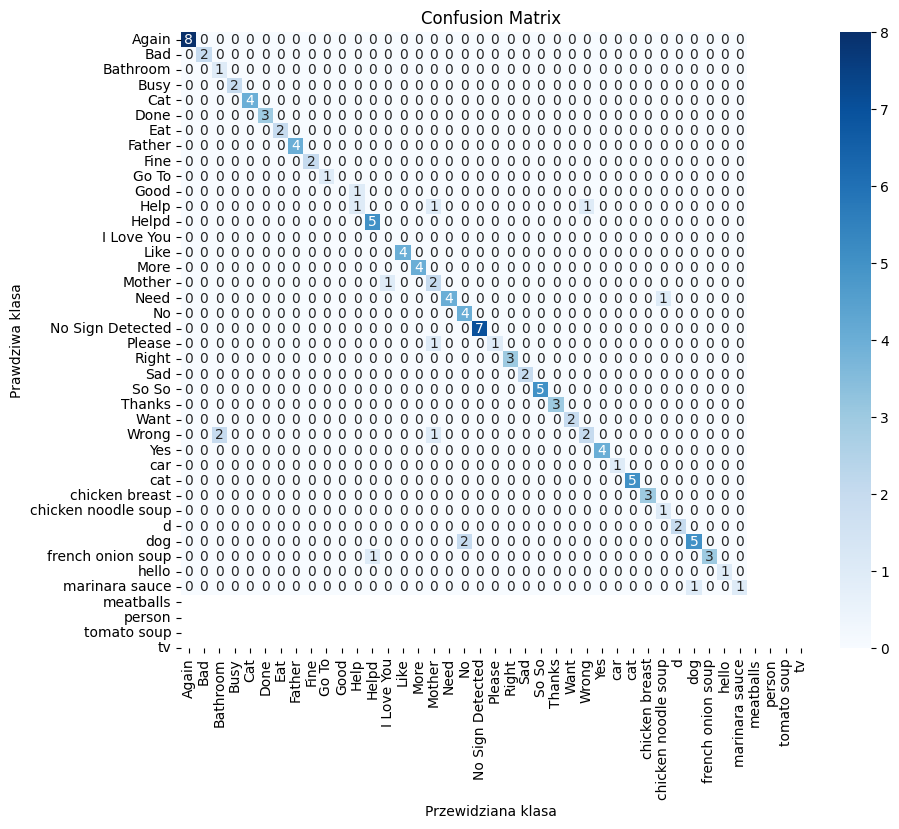

ValueError: Number of classes, 37, does not match size of target_names, 41. Try specifying the labels parameter

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Predykcja na zbiorze testowym
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Macierz pomyłek
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Wykres
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.title('Confusion Matrix')
plt.show()

# 4. Raport tekstowy
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))

Predykcja: More z pewnością 99.77%


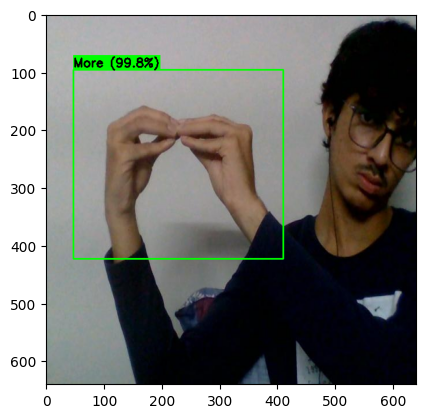

In [119]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_full_pipeline(image_path, detector_model, classifier_model, classes_list):
    # Ustawienia (muszą być takie same jak przy treningu)
    IMG_SIZE = 224
    PADDING = 20

    # 1. Wczytanie obrazu
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Błąd: Nie można wczytać obrazu {image_path}")
        return

    h_orig, w_orig, _ = img_bgr.shape
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # =========================================================
    # KROK 1: DETEKCJA (Gdzie jest dłoń?)
    # =========================================================
    
    # Preprocessing dla detektora
    img_det = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_det_batch = np.expand_dims(img_det, axis=0) # Kształt: (1, 224, 224, 3)

    # Predykcja ramki
    box_norm = detector_model.predict(img_det_batch, verbose=0)[0]
    
    # Denormalizacja (0.0-1.0 -> piksele)
    x = int(box_norm[0] * w_orig)
    y = int(box_norm[1] * h_orig)
    w = int(box_norm[2] * w_orig)
    h = int(box_norm[3] * h_orig)

    # Dodanie marginesu (Padding) - ważne, bo klasyfikator uczył się na luźniejszych kadrach
    x_pad = max(0, x - PADDING)
    y_pad = max(0, y - PADDING)
    w_pad = min(w_orig - x_pad, w + 2 * PADDING)
    h_pad = min(h_orig - y_pad, h + 2 * PADDING)

    # Wycięcie dłoni
    hand_crop = img_rgb[y_pad : y_pad+h_pad, x_pad : x_pad+w_pad]

    # Zabezpieczenie przed pustym wycinkiem (gdyby detektor zawiódł)
    if hand_crop.size == 0:
        print("Nie udało się wyciąć dłoni (błąd detektora).")
        return

    # =========================================================
    # KROK 2: KLASYFIKACJA (Jaki to gest?)
    # =========================================================

    # Preprocessing dla klasyfikatora
    img_cls = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_cls_batch = np.expand_dims(img_cls, axis=0)

    # Predykcja gestu
    predictions = classifier_model.predict(img_cls_batch, verbose=0)[0]
    class_idx = np.argmax(predictions)       # Indeks najwyższego wyniku
    confidence = predictions[class_idx]      # Pewność (0.0 - 1.0)
    
    predicted_label = classes_list[class_idx]
    
    print(f"Predykcja: {predicted_label} z pewnością {confidence*100:.2f}%")

    # =========================================================
    # KROK 3: WIZUALIZACJA
    # =========================================================
    
    # Kolor ramki zależny od pewności (Zielony = pewny, Żółty = niepewny)
    color = (0, 255, 0) if confidence > 0.7 else (0, 255, 255)

    # Rysujemy ramkę na ORYGINALNYM obrazie BGR
    cv2.rectangle(img_bgr, (x_pad, y_pad), (x_pad + w_pad, y_pad + h_pad), color, 2)

    # Przygotowanie tekstu: "I love You (98%)"
    text = f"{predicted_label} ({confidence*100:.1f}%)"
    
    # Tło pod napisem (dla czytelności)
    (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.rectangle(img_bgr, (x_pad, y_pad - 25), (x_pad + text_w, y_pad), color, -1)
    
    # Napis
    cv2.putText(img_bgr, text, (x_pad, y_pad - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    # Pokazanie wyniku
    cropped_img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(cropped_img_rgb)
    # cv2.imshow("Wynik Pipeline", img_bgr)
    
    # Opcjonalnie: Pokaż też, co "widział" klasyfikator (wycinek)
    # cv2.imshow("Co widzi klasyfikator", cv2.cvtColor(hand_crop, cv2.COLOR_RGB2BGR))
    
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# -----------------------------------------------------------
# PRZYKŁAD UŻYCIA
# -----------------------------------------------------------

# 1. Definicja klas (kolejność musi być identyczna jak przy treningu!)
# CLASSES = ['Yes', 'No', 'Hello']

# 2. Wczytanie modeli (jeśli jeszcze nie są w pamięci)
detector = tf.keras.models.load_model('hand_detector_best.keras')
classifier = tf.keras.models.load_model('gesture_classifier.keras')

# 3. Uruchomienie funkcji
predict_full_pipeline("./Sign Language Detection/hindusi/test/images/More-0ccc3b1a-85ad-11ef-aecc-8cec4b00b636_jpg.rf.264775b3f66d1b497129972d6a7b8498.jpg", detector, classifier, CLASSES)